# MIMIC-Extract Experiment Statistics
This notebook visualizes the number of entries (ICU stays) and the statistics (mean, median, standard deviation) for the clinical variables across the different extraction scenarios.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.2)

# Load the computed statistics
with open('../experiment_stats.json', 'r') as f:
    stats = json.load(f)

print(f"Loaded stats for {len(stats)} experiments.")

Loaded stats for 12 experiments.


## 1. Number of Entries per Experiment

/tmp/ipykernel_3524640/223500856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_entries.index, y=df_entries['Number of Entries'], palette='viridis')


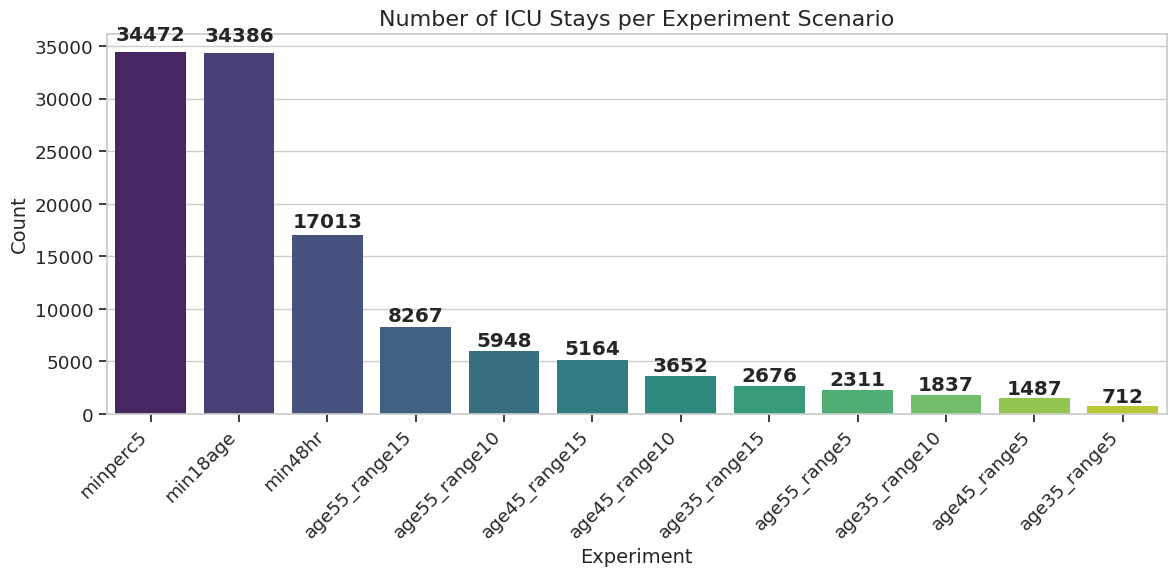

In [2]:
entries = {exp: data['num_entries'] for exp, data in stats.items()}
df_entries = pd.DataFrame.from_dict(entries, orient='index', columns=['Number of Entries'])
df_entries = df_entries.sort_values('Number of Entries', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=df_entries.index, y=df_entries['Number of Entries'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Number of ICU Stays per Experiment Scenario', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Experiment', fontsize=14)

# Add value labels on top of bars
for i, v in enumerate(df_entries['Number of Entries']):
    ax.text(i, v + (v*0.02), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Clinical Variable Statistics
Let's look at the mean and standard deviation for a few key vital signs across the different experiments.

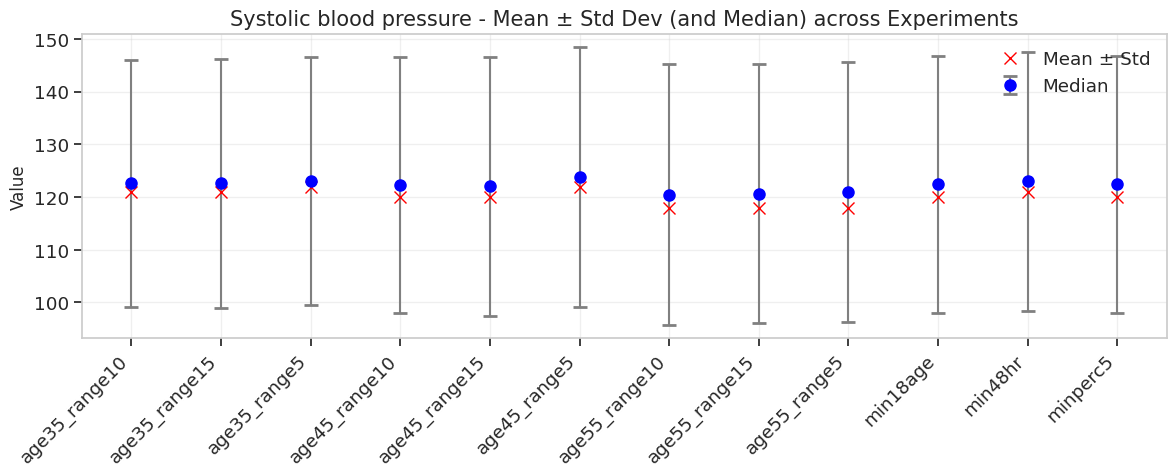

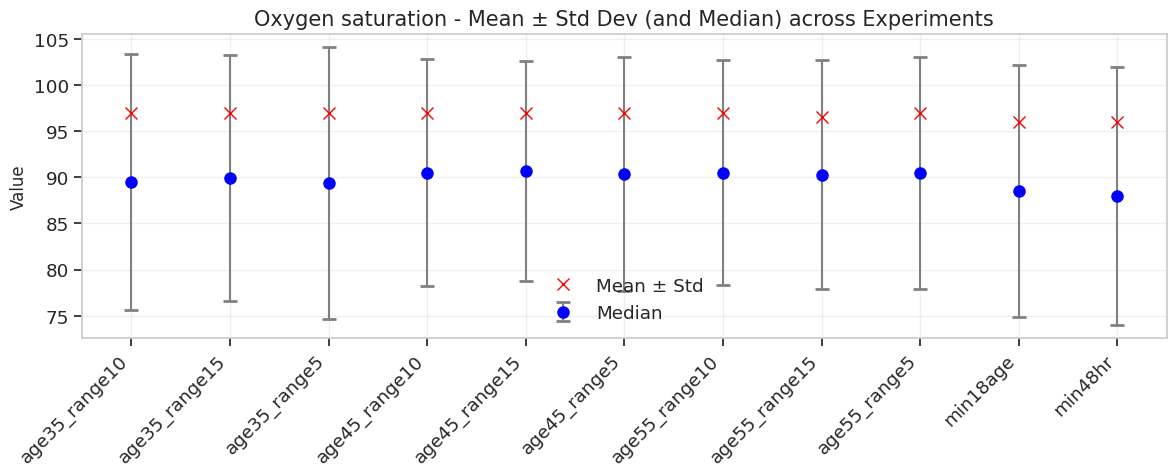

In [3]:
key_vitals = ['Heart Rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Temperature', 'Respiratory rate', 'Oxygen saturation']

for vital in key_vitals:
    vital_stats = []
    for exp, data in stats.items():
        if vital in data['variables']:
            v_data = data['variables'][vital]
            vital_stats.append({
                'Experiment': exp,
                'Mean': v_data['mean'],
                'Median': v_data['median'],
                'Std': v_data['std']
            })
    
    if not vital_stats:
        continue
        
    df_v = pd.DataFrame(vital_stats).sort_values('Experiment')
    
    plt.figure(figsize=(12, 5))
    plt.errorbar(x=df_v['Experiment'], y=df_v['Mean'], yerr=df_v['Std'], 
                 fmt='o', capsize=5, capthick=2, markersize=8, color='b', ecolor='gray')
    plt.plot(df_v['Experiment'], df_v['Median'], 'rx', markersize=8, label='Median')
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{vital} - Mean ± Std Dev (and Median) across Experiments', fontsize=15)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(['Mean ± Std', 'Median'])
    plt.tight_layout()
    plt.show()

## 3. Heatmap of Variable Means
To see how the mean values of all variables compare across experiments, we can plot a heatmap. We will normalize the values per variable (z-score) to make them comparable on the same color scale.

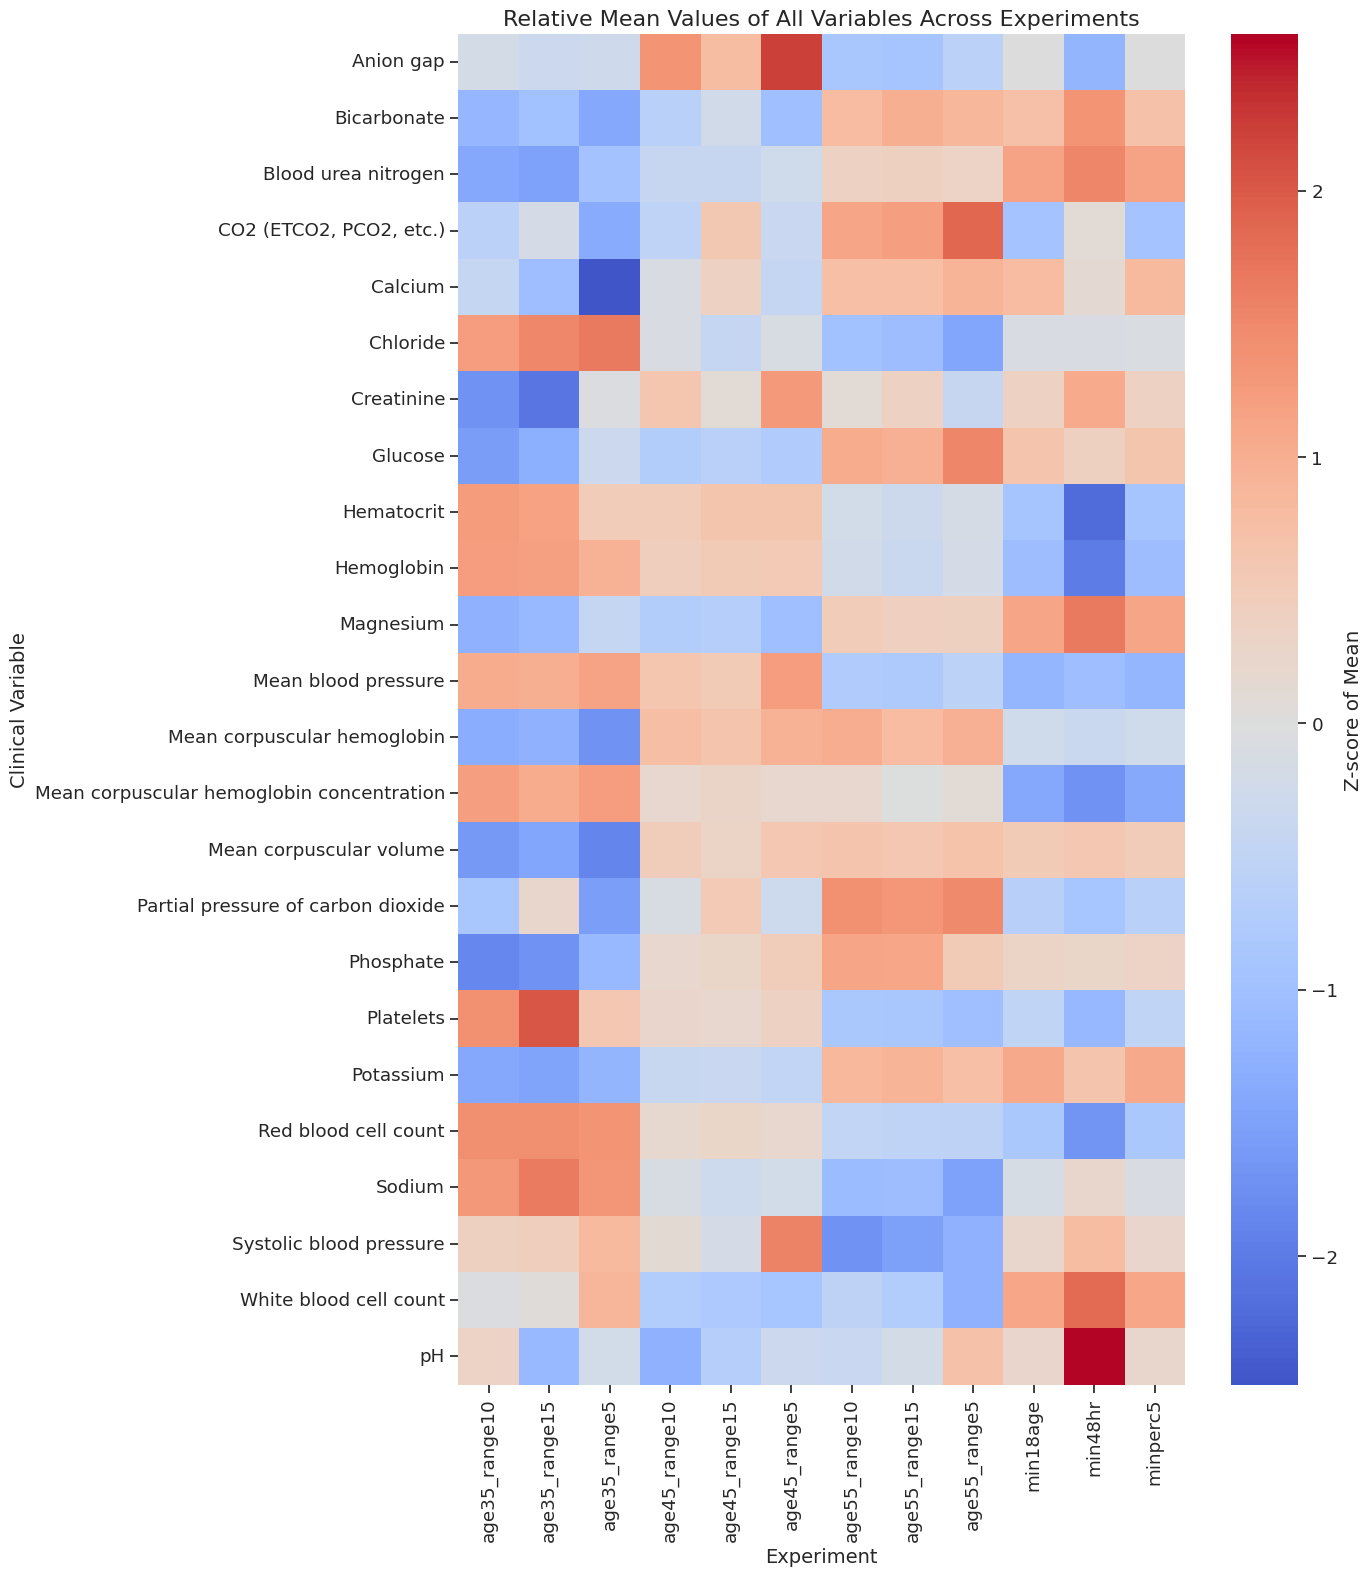

In [4]:
# Build a dataframe of all means
all_means = {}
for exp, data in stats.items():
    all_means[exp] = {var: vals['mean'] for var, vals in data['variables'].items()}

df_all_means = pd.DataFrame(all_means)

# Drop variables that have NaNs in any experiment to ensure a clean heatmap
df_all_means = df_all_means.dropna()

# Normalize row-wise (per variable) to see relative differences between experiments
df_normalized = df_all_means.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

plt.figure(figsize=(14, 16))
sns.heatmap(df_normalized, cmap='coolwarm', center=0, cbar_kws={'label': 'Z-score of Mean'})
plt.title('Relative Mean Values of All Variables Across Experiments', fontsize=16)
plt.xlabel('Experiment', fontsize=14)
plt.ylabel('Clinical Variable', fontsize=14)
plt.tight_layout()
plt.show()